# Codveda Internship — Level 3 (Advanced)

Covers:
- Task 1: Predictive Modeling / Classification (dataset: `Churn Prdiction Data/`)
- Task 3: NLP — Sentiment Analysis (dataset: `3) Sentiment dataset.csv`)

> Task 2 (Building Dashboards with Power BI/Tableau) is **not a Python/Kaggle task** —
> it's done separately in the Power BI Desktop or Tableau app. See the note at the bottom
> of this notebook for what to do there. Per the instructions you only need **2 of the 3**
> tasks per level, so Task 1 + Task 3 here are enough — treat the dashboard as a bonus.

**Kaggle setup:** path below already confirmed working (`smminhajchowdhury/data-set-for-task`).
For `nltk`, Kaggle notebooks usually have it preinstalled; if a resource download fails,
uncomment the `nltk.download(...)` lines (Kaggle needs internet turned ON in notebook settings).

In [27]:
import os

# 1. See what's inside /kaggle/input/
print("Top-level folders in /kaggle/input/:")
print(os.listdir("/kaggle/input/"))

# 2. Walk into each folder to see the actual file names/paths
for root, dirs, files in os.walk("/kaggle/input/"):
    for f in files:
        print(os.path.join(root, f))



Top-level folders in /kaggle/input/:
['datasets']
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/2) Stock Prices Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/1) iris.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/4) house Prediction Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/3) Sentiment dataset.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "."
print(os.listdir(DATA_DIR))

['2) Stock Prices Data Set.csv', 'Churn Prdiction Data', '1) iris.csv', '4) house Prediction Data Set.csv', '3) Sentiment dataset.csv']


## Task 1: Predictive Modeling (Classification) — Customer Churn

In [29]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

churn_dir = os.path.join(DATA_DIR, "Churn Prdiction Data")
train_df = pd.read_csv(os.path.join(churn_dir, "churn-bigml-80.csv"))
test_df  = pd.read_csv(os.path.join(churn_dir, "churn-bigml-20.csv"))

train_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [30]:
# Preprocess: encode categorical variables
def preprocess(df, encoders=None, fit=False):
    df = df.copy()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    bool_cols = df.select_dtypes(include='bool').columns.tolist()

    if encoders is None:
        encoders = {}

    for col in cat_cols:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
        else:
            le = encoders[col]
            df[col] = le.transform(df[col])

    for col in bool_cols:
        df[col] = df[col].astype(int)

    return df, encoders

train_proc, encoders = preprocess(train_df, fit=True)
test_proc, _ = preprocess(test_df, encoders=encoders, fit=False)

X_train = train_proc.drop(columns=["Churn"])
y_train = train_proc["Churn"]
X_test = test_proc.drop(columns=["Churn"])
y_test = test_proc["Churn"]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# Train and compare multiple models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.853073,0.459459,0.178947,0.257576
1,Decision Tree,0.917541,0.704082,0.726316,0.715026
2,Random Forest,0.946027,0.953846,0.652632,0.775000


In [32]:
# Hyperparameter tuning with GridSearchCV (Random Forest)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

best_preds = best_model.predict(X_test_scaled)
print(classification_report(y_test, best_preds))

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.96      0.69      0.80        95

    accuracy                           0.95       667
   macro avg       0.95      0.84      0.89       667
weighted avg       0.95      0.95      0.95       667



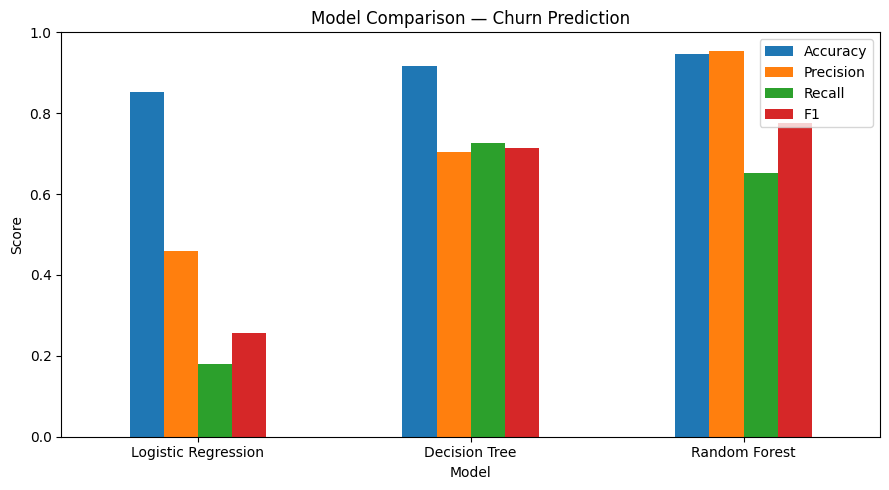

In [33]:
# Visualize model comparison
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar", figsize=(9,5), ylim=(0,1))
plt.title("Model Comparison — Churn Prediction")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("churn_model_comparison.png")
plt.show()

## Task 3: NLP — Sentiment Analysis

In [34]:
import re
import nltk
# If these fail on Kaggle, turn on Internet in notebook settings, then uncomment:
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

sent_path = os.path.join(DATA_DIR, "3) Sentiment dataset.csv")
sent_df = pd.read_csv(sent_path)

# Clean column names and whitespace-padded text/labels
sent_df.columns = [c.strip() for c in sent_df.columns]
sent_df["Text"] = sent_df["Text"].astype(str).str.strip()
sent_df["Sentiment"] = sent_df["Sentiment"].astype(str).str.strip()

sent_df[["Text", "Sentiment"]].head()

,Text,Sentiment
0,Enjoying a beautiful day at the park!,Positive
1,Traffic was terrible this morning.,Negative
2,Just finished an amazing workout! 💪,Positive
3,Excited about the upcoming weekend getaway!,Positive
4,Trying out a new recipe for dinner tonight.,Neutral


**Note:** the `Sentiment` column in this file has many fine-grained labels
(joy, excitement, gratitude, despair, etc.), not just positive/negative/neutral.
That's fine for the "visualize sentiment distribution" objective as-is. If you want
a strict 3-class comparison against TextBlob's output, you can map similar labels
into `positive` / `negative` / `neutral` buckets — optional, not required by the task.

In [35]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|@\w+|#\w+", "", text)     # remove urls, mentions, hashtags
    text = re.sub(r"[^a-z\s]", "", text)               # keep only letters
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

sent_df["clean_text"] = sent_df["Text"].apply(clean_text)
sent_df[["Text", "clean_text"]].head()

,Text,clean_text
0,Enjoying a beautiful day at the park!,enjoying beautiful day park
1,Traffic was terrible this morning.,traffic terrible morning
2,Just finished an amazing workout! 💪,finished amazing workout
3,Excited about the upcoming weekend getaway!,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight.,trying new recipe dinner tonight


In [36]:
from textblob import TextBlob

def get_polarity_label(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return "positive"
    elif polarity < -0.05:
        return "negative"
    else:
        return "neutral"

sent_df["predicted_sentiment"] = sent_df["clean_text"].apply(get_polarity_label)
sent_df[["Text", "Sentiment", "predicted_sentiment"]].head(10)

,Text,Sentiment,predicted_sentiment
0,Enjoying a beautiful day at the park!,Positive,positive
1,Traffic was terrible this morning.,Negative,negative
2,Just finished an amazing workout! 💪,Positive,positive
3,Excited about the upcoming weekend getaway!,Positive,positive
4,Trying out a new recipe for dinner tonight.,Neutral,positive
5,Feeling grateful for the little things in life.,Positive,negative
6,Rainy days call for cozy blankets and hot cocoa.,Positive,neutral
7,The new movie release is a must-watch!,Positive,positive
8,Political discussions heating up on the timeline.,Negative,neutral
9,Missing summer vibes and beach days.,Neutral,negative


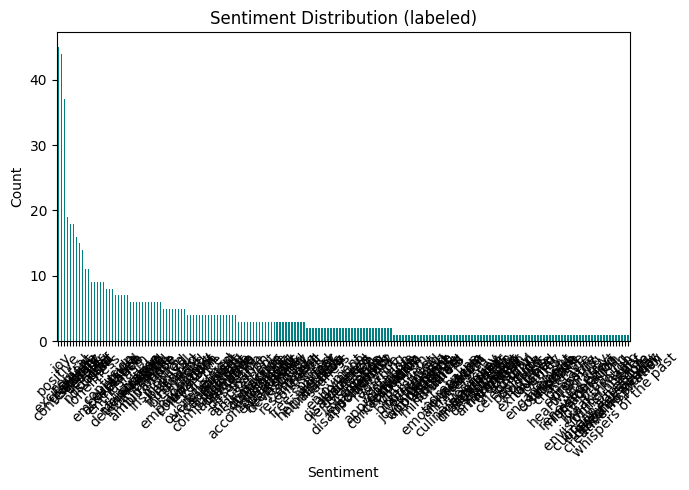

In [37]:
# Visualize sentiment distribution (labeled data from the dataset itself)
plt.figure(figsize=(7,5))
sent_df["Sentiment"].str.lower().value_counts().plot(kind="bar", color="teal")
plt.title("Sentiment Distribution (labeled)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sentiment_distribution.png")
plt.show()

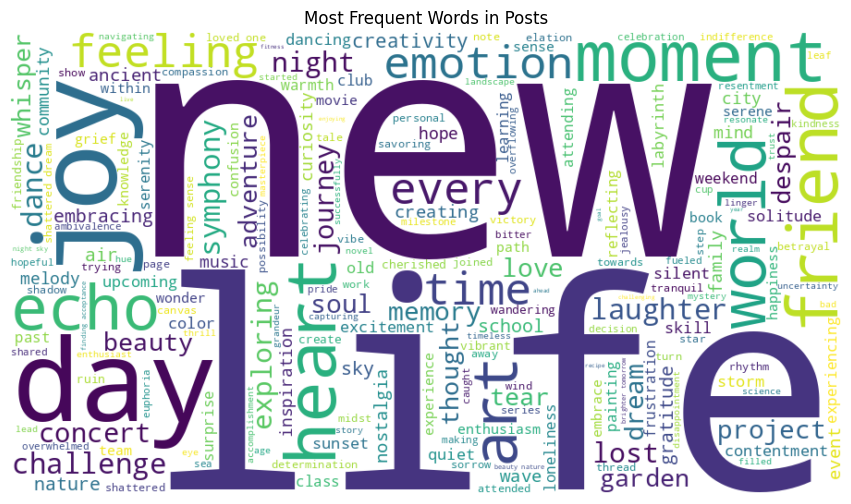

In [38]:
# Word cloud of most frequent words
# If wordcloud isn't installed, uncomment: !pip install wordcloud -q
from wordcloud import WordCloud

all_words = " ".join(sent_df["clean_text"])
wc = WordCloud(width=900, height=500, background_color="white").generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Posts")
plt.savefig("sentiment_wordcloud.png")
plt.show()